<a href="https://colab.research.google.com/github/Not-Baguette/Bagu-Archive/blob/main/Alzheimer_Detection_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Deep Learning for Multi-Stage Alzheimer's Disease Detection from Brain MRI

**Dataset**: OASIS Alzheimer's Detection (Kaggle)

**Pipeline Overview**:
1. Setup & Dataset Download
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing & Augmentation
4. Dataset Splitting & DataLoaders
5. Model Architecture (ResNet50, EfficientNet-B0, VGG16)
6. Model Training
7. Model Evaluation
8. Explainability (Grad-CAM)
9. Model Comparison & Final Results

---

## Phase 1: Setup & Dataset Download

### 1.1 Enable GPU

Before running anything:
1. Go to **Runtime → Change runtime type**
2. Select **T4 GPU** (or any available GPU)
3. Click **Save**

In [11]:
# Verify GPU is available
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU detected! Go to Runtime > Change runtime type > GPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [12]:
# Install required packages
!pip install -q kaggle

### 1.2 Download Dataset from Kaggle

**Steps to get your Kaggle API key:**
1. Go to https://www.kaggle.com/settings
2. Scroll to **API** section
3. Click **Create New Token** — this downloads `kaggle.json`
4. Upload it in the cell below

In [13]:
from google.colab import files
uploaded = files.upload()  # Upload kaggle.json here

import os
uploaded_filename = list(uploaded.keys())[0]

if uploaded_filename != 'kaggle.json':
    os.rename(uploaded_filename, 'kaggle.json')
    print(f"Renamed '{uploaded_filename}' -> 'kaggle.json'")

print("kaggle.json is ready!")

Saving kaggle.json to kaggle.json
kaggle.json is ready!


In [14]:
# Setup Kaggle credentials and download dataset
import os

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the OASIS dataset
!kaggle datasets download -d ninadaithal/imagesoasis -p ./dataset --unzip

print("\nDownload complete!")

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:06<00:00, 271MB/s]
100% 1.23G/1.23G [00:06<00:00, 215MB/s]

Download complete!


In [15]:
# Find the actual data directory
# The dataset may extract into nested folders — let's find where the class folders are

import os

os.makedirs("checkpoints", exist_ok=True)

def find_data_dir(root='./dataset'):
    """Walk the directory tree to find the folder containing class subfolders."""
    target_classes = {'Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia'}
    # Also check alternate names
    alt_classes = {'mild_demented', 'moderate_demented', 'non_demented', 'very_mild_demented'}

    for dirpath, dirnames, filenames in os.walk(root):
        dir_set = set(dirnames)
        if target_classes.issubset(dir_set) or alt_classes.issubset(dir_set):
            return dirpath

    # If exact match not found, print what we have
    print("Could not auto-detect. Directory structure:")
    for dirpath, dirnames, filenames in os.walk(root):
        level = dirpath.replace(root, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(dirpath)}/")
        if level < 3:
            for d in dirnames:
                print(f"{indent}  {d}/")
    return None

DATA_DIR = find_data_dir('./dataset')
print(f"Data directory found: {DATA_DIR}")
print(f"Contents: {os.listdir(DATA_DIR)}")

Data directory found: ./dataset/Data
Contents: ['Moderate Dementia', 'Very mild Dementia', 'Non Demented', 'Mild Dementia']


---
## Phase 2: Exploratory Data Analysis (EDA)

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import warnings
warnings.filterwarnings('ignore')

# Define class names (consistent ordering throughout the notebook)
CLASS_NAMES = ['Non Demented', 'Very mild Dementia', 'Mild Dementia', 'Moderate Dementia']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

DATASET OVERVIEW


### 2.1 Count Images Per Class

In [17]:
class_counts = {}
total_images = 0

for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        class_counts[cls] = count
        total_images += count
        print(f"  {cls:25s} : {count:>6,} images ({count/total_images*100 if total_images > 0 else 0:.1f}%)")

print(f"\n  {'TOTAL':25s} : {total_images:>6,} images")
print(f"\n  Imbalance ratio (max/min): {max(class_counts.values()) / max(min(class_counts.values()), 1):.0f}:1")

  Mild Dementia             :  5,002 images (100.0%)
  Moderate Dementia         :    488 images (8.9%)
  Non Demented              : 67,222 images (92.4%)
  Very mild Dementia        : 13,725 images (15.9%)

  TOTAL                     : 86,437 images

  Imbalance ratio (max/min): 138:1


### 2.2 Class Distribution Bar Chart

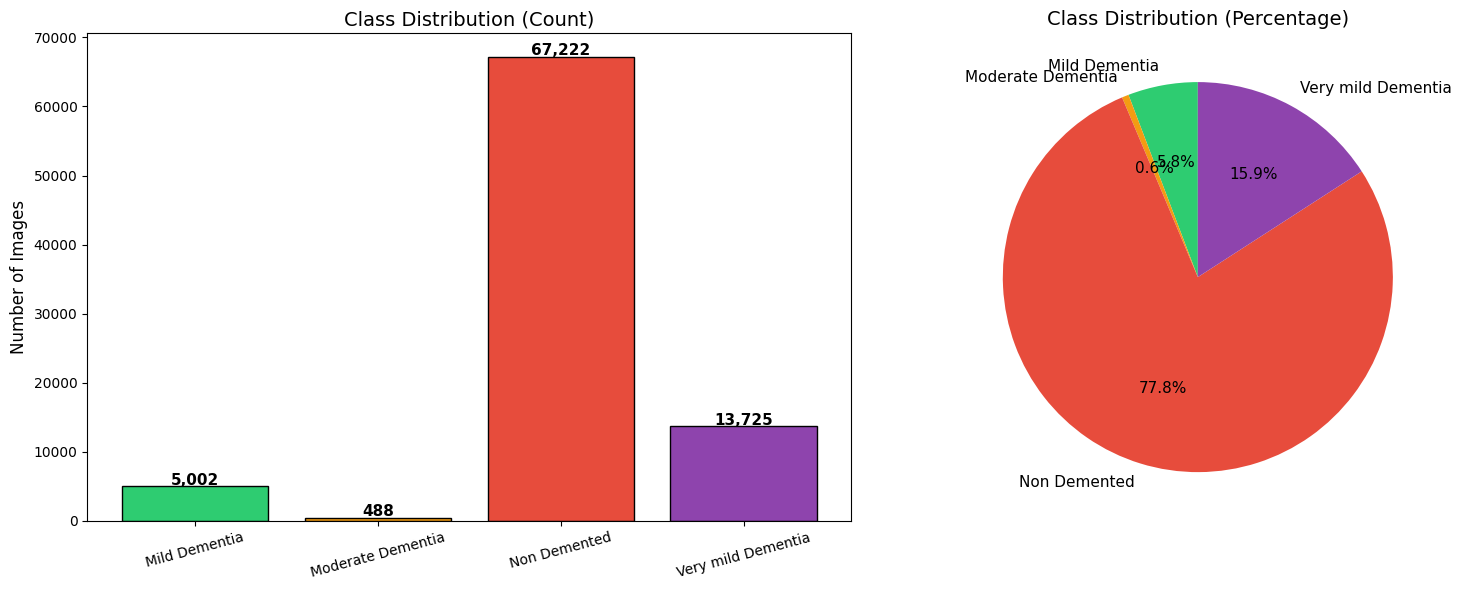

Saved: class_distribution.png


In [18]:
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
bars = axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black')
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{count:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: class_distribution.png")

### 2.3 Visualize Sample MRI Images

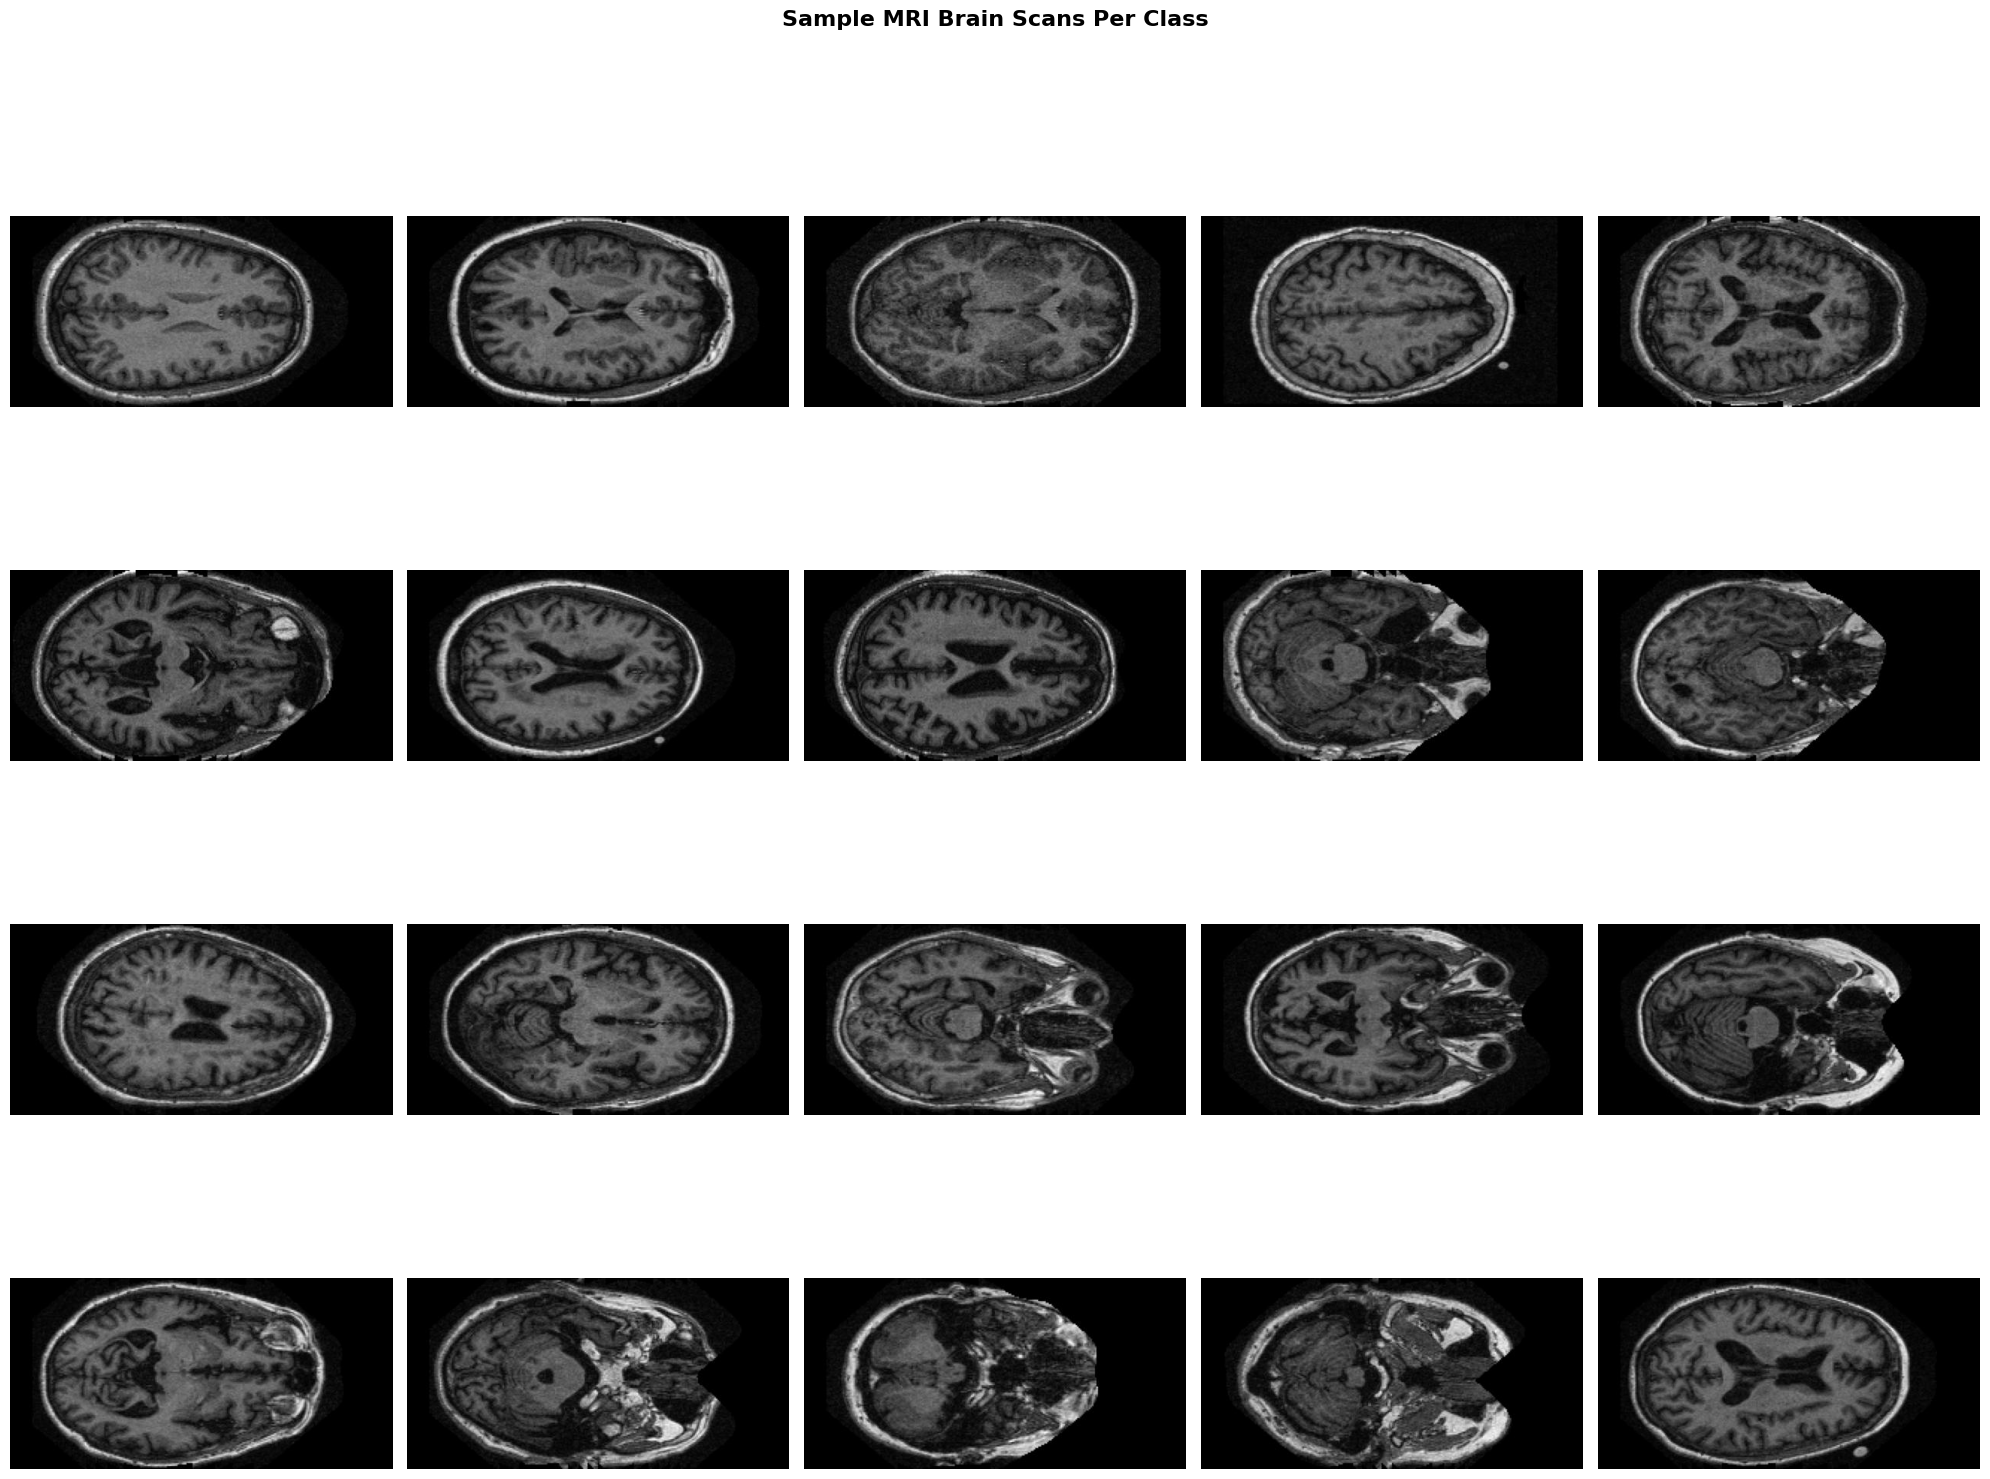

Saved: sample_images.png


In [19]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_DIR, cls)
    all_images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    samples = random.sample(all_images, min(5, len(all_images)))

    for col, img_name in enumerate(samples):
        img = Image.open(os.path.join(cls_path, img_name))
        axes[row][col].imshow(img, cmap='gray')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0,
                                       labelpad=120, va='center')
        axes[row][col].axis('off')

plt.suptitle('Sample MRI Brain Scans Per Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_images.png")

### 2.4 Check Image Properties

In [20]:
print("Checking image properties across all classes...\n")

sizes = set()
modes = set()

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_DIR, cls)
    all_imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    # Check a random sample of 20 images per class
    for img_name in random.sample(all_imgs, min(20, len(all_imgs))):
        img = Image.open(os.path.join(cls_path, img_name))
        sizes.add(img.size)
        modes.add(img.mode)

print(f"  Unique image sizes found : {sizes}")
print(f"  Image modes found        : {modes}")
print(f"  All same size?           : {'Yes' if len(sizes) == 1 else 'No — resizing required'}")
print(f"  Color mode               : {'Grayscale' if modes == {'L'} else 'RGB' if modes == {'RGB'} else modes}")

Checking image properties across all classes...

  Unique image sizes found : {(496, 248)}
  Image modes found        : {'RGB'}
  All same size?           : Yes
  Color mode               : RGB


### 2.5 Check for Corrupted Images

In [21]:
print("Scanning for corrupted images...")

corrupted = []
total_checked = 0

for cls in CLASS_NAMES:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        total_checked += 1
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception as e:
            corrupted.append(img_path)

print(f"  Total images checked : {total_checked:,}")
print(f"  Corrupted images     : {len(corrupted)}")

if corrupted:
    print("\n  Removing corrupted files...")
    for f in corrupted:
        os.remove(f)
        print(f"    Removed: {f}")
    print("  Done.")
else:
    print("  All images are valid!")

Scanning for corrupted images...
  Total images checked : 86,437
  Corrupted images     : 0
  All images are valid!


---
## Phase 3: Data Preprocessing & Augmentation

### Key preprocessing steps:
- **Resize** all images to 224×224 (required for pretrained models)
- **Convert grayscale → RGB** (pretrained models expect 3 channels)
- **Normalize** with ImageNet mean/std
- **Augment** training set to increase diversity and reduce overfitting

In [22]:
from torchvision import transforms

# --- Image dimensions ---
IMG_SIZE = 224

# --- ImageNet normalization stats ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Training transforms (WITH augmentation) ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# --- Validation/Test transforms (NO augmentation) ---
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms defined.")
print(f"  Image size   : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Channels     : 3 (grayscale → RGB)")
print(f"  Normalization: ImageNet mean/std")
print(f"  Augmentation : HorizontalFlip, Rotation(±10°), Affine, ColorJitter")

Transforms defined.
  Image size   : 224x224
  Channels     : 3 (grayscale → RGB)
  Normalization: ImageNet mean/std
  Augmentation : HorizontalFlip, Rotation(±10°), Affine, ColorJitter


### 3.1 Visualize Augmented vs Original Images

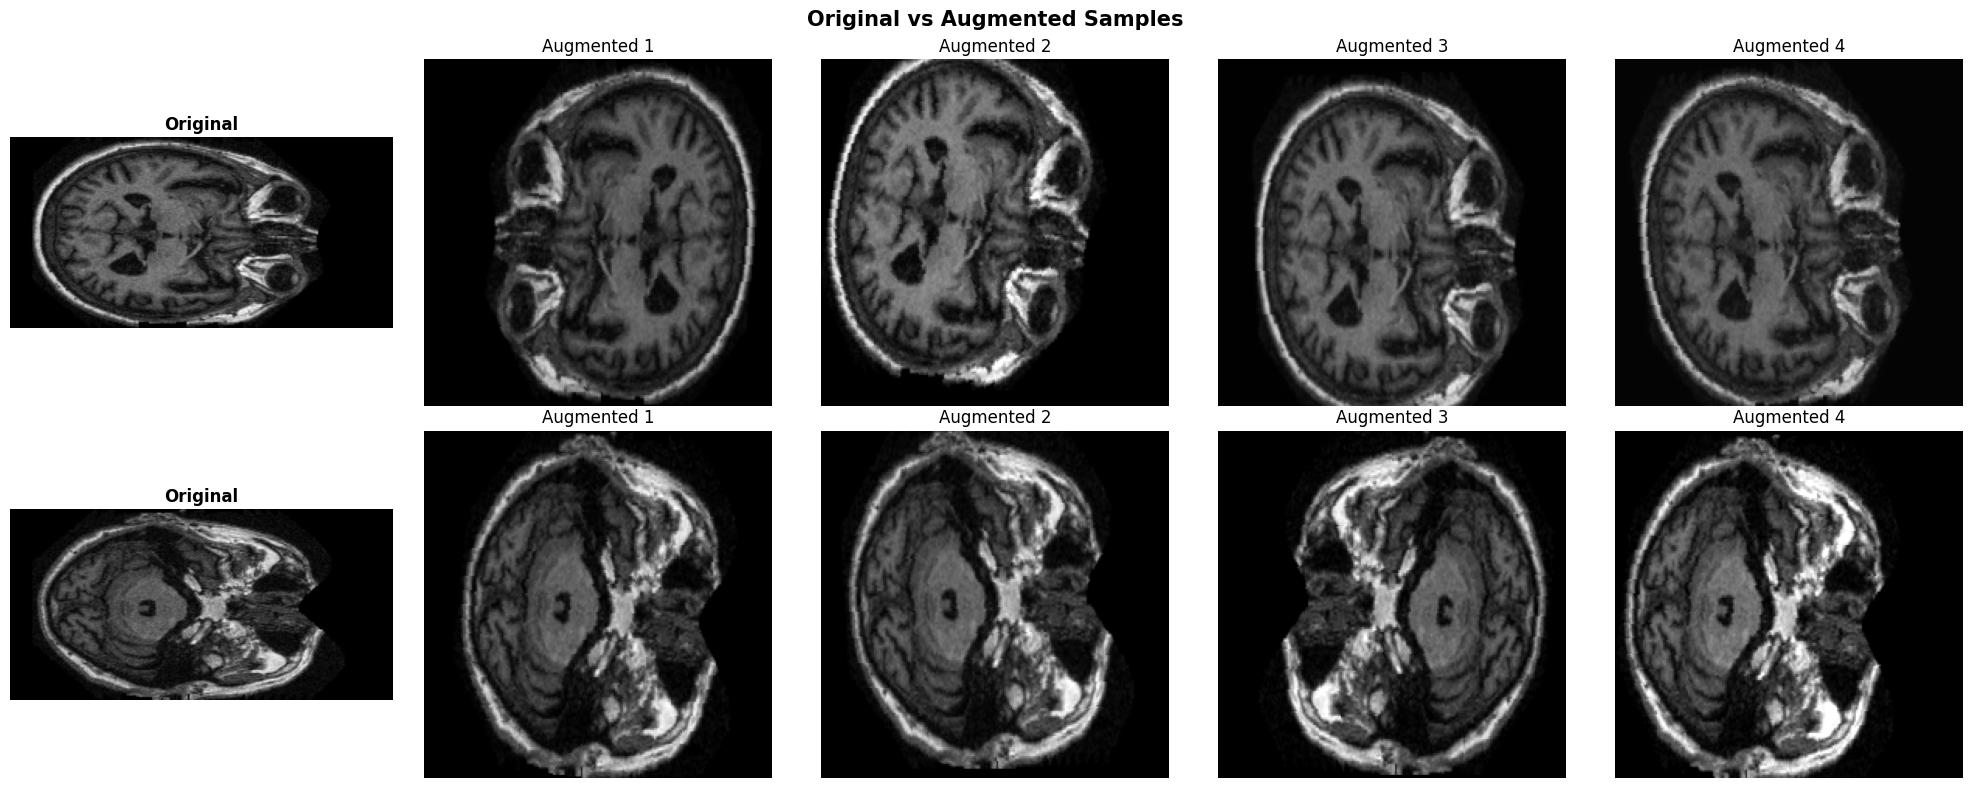

In [23]:
# Show original vs augmented versions of the same image
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Pick a sample image
sample_cls = 'Mild Dementia'
cls_path = os.path.join(DATA_DIR, sample_cls)
sample_img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
sample_img = Image.open(sample_img_path)

# Show original
axes[0][0].imshow(sample_img, cmap='gray')
axes[0][0].set_title('Original', fontsize=12, fontweight='bold')
axes[0][0].axis('off')

# Show augmented versions
for i in range(1, 5):
    aug_tensor = train_transform(sample_img.copy())
    aug_img = denormalize(aug_tensor).permute(1, 2, 0).numpy()
    axes[0][i].imshow(aug_img)
    axes[0][i].set_title(f'Augmented {i}', fontsize=12)
    axes[0][i].axis('off')

# Same for another class
sample_cls2 = 'Moderate Dementia'
cls_path2 = os.path.join(DATA_DIR, sample_cls2)
sample_img2 = Image.open(os.path.join(cls_path2, os.listdir(cls_path2)[0]))

axes[1][0].imshow(sample_img2, cmap='gray')
axes[1][0].set_title('Original', fontsize=12, fontweight='bold')
axes[1][0].axis('off')

for i in range(1, 5):
    aug_tensor = train_transform(sample_img2.copy())
    aug_img = denormalize(aug_tensor).permute(1, 2, 0).numpy()
    axes[1][i].imshow(aug_img)
    axes[1][i].set_title(f'Augmented {i}', fontsize=12)
    axes[1][i].axis('off')

axes[0][0].set_ylabel('Mild Dementia', fontsize=12, fontweight='bold')
axes[1][0].set_ylabel('Moderate Dementia', fontsize=12, fontweight='bold')

plt.suptitle('Original vs Augmented Samples', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 4: Dataset Splitting & DataLoaders

- **70% Train / 15% Validation / 15% Test**
- **Stratified split** to preserve class ratios in every split
- **Weighted sampler** to handle class imbalance during training

In [24]:
from sklearn.model_selection import train_test_split
import shutil

# Collect all image paths and their labels
all_images = []
all_labels = []

for label, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(cls_path, img_name))
            all_labels.append(label)

print(f"Total images collected: {len(all_images)}")

# Stratified split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):>6,} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"  Val   : {len(X_val):>6,} ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"  Test  : {len(X_test):>6,} ({len(X_test)/len(all_images)*100:.1f}%)")

Total images collected: 86437

Split sizes:
  Train : 60,505 (70.0%)
  Val   : 12,966 (15.0%)
  Test  : 12,966 (15.0%)


In [25]:
# Organize into folder structure for ImageFolder
SPLIT_DIR = './dataset_split'

def copy_files_to_split(file_list, label_list, split_name):
    """Copy files into train/val/test folder structure."""
    count = 0
    for fpath, label in zip(file_list, label_list):
        cls_name = CLASS_NAMES[label]
        dest_dir = os.path.join(SPLIT_DIR, split_name, cls_name)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy2(fpath, dest_dir)
        count += 1
    return count

# Remove old splits if they exist
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

print("Copying files into split folders...")
n_train = copy_files_to_split(X_train, y_train, 'train')
n_val   = copy_files_to_split(X_val, y_val, 'val')
n_test  = copy_files_to_split(X_test, y_test, 'test')
print(f"  Copied — Train: {n_train:,}, Val: {n_val:,}, Test: {n_test:,}")

Copying files into split folders...
  Copied — Train: 60,505, Val: 12,966, Test: 12,966


In [26]:
# Verify split class distribution
print("\nClass distribution per split:\n")
print(f"{'Class':<25s} {'Train':>8s} {'Val':>8s} {'Test':>8s}")
print("-" * 55)

for cls in CLASS_NAMES:
    tr = len(os.listdir(os.path.join(SPLIT_DIR, 'train', cls)))
    va = len(os.listdir(os.path.join(SPLIT_DIR, 'val', cls)))
    te = len(os.listdir(os.path.join(SPLIT_DIR, 'test', cls)))
    print(f"{cls:<25s} {tr:>8,} {va:>8,} {te:>8,}")


Class distribution per split:

Class                        Train      Val     Test
-------------------------------------------------------
Non Demented                47,055   10,083   10,084
Very mild Dementia           9,607    2,059    2,059
Mild Dementia                3,501      751      750
Moderate Dementia              342       73       73


In [27]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter

# Create datasets
train_dataset = ImageFolder(root=os.path.join(SPLIT_DIR, 'train'), transform=train_transform)
val_dataset   = ImageFolder(root=os.path.join(SPLIT_DIR, 'val'),   transform=val_transform)
test_dataset  = ImageFolder(root=os.path.join(SPLIT_DIR, 'test'),  transform=val_transform)

print(f"Classes          : {train_dataset.classes}")
print(f"Class-to-index   : {train_dataset.class_to_idx}")
print(f"Train samples    : {len(train_dataset):,}")
print(f"Val samples      : {len(val_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")

Classes          : ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Class-to-index   : {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}
Train samples    : 60,505
Val samples      : 12,966
Test samples     : 12,966


In [28]:
# --- Weighted Random Sampler (handles class imbalance) ---

# Count samples per class in training set
train_labels = [label for _, label in train_dataset.samples]
label_counts = Counter(train_labels)
total_train = len(train_labels)

print("Training set class counts:")
for cls_idx, count in sorted(label_counts.items()):
    print(f"  {CLASS_NAMES[cls_idx]}: {count:,}")

# Compute weight for each class (inverse frequency)
class_weights_list = [total_train / label_counts[i] for i in range(len(CLASS_NAMES))]

# Assign weight to each sample
sample_weights = [class_weights_list[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print(f"\nClass weights (inverse frequency):")
for i, w in enumerate(class_weights_list):
    print(f"  {CLASS_NAMES[i]}: {w:.4f}")

Training set class counts:
  Non Demented: 3,501
  Very mild Dementia: 342
  Mild Dementia: 47,055
  Moderate Dementia: 9,607

Class weights (inverse frequency):
  Non Demented: 17.2822
  Very mild Dementia: 176.9152
  Mild Dementia: 1.2858
  Moderate Dementia: 6.2980


In [29]:
# --- Create DataLoaders ---

BATCH_SIZE = 32
NUM_WORKERS = 2  # Colab usually supports 2

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Verify a batch
images, labels = next(iter(train_loader))
print(f"Batch shape  : {images.shape}")   # [32, 3, 224, 224]
print(f"Labels shape : {labels.shape}")    # [32]
print(f"Label values : {labels.tolist()}")  # Should show all classes represented

Batch shape  : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Label values : [2, 0, 0, 3, 1, 2, 3, 1, 2, 3, 3, 0, 1, 2, 0, 3, 1, 3, 2, 2, 0, 3, 1, 0, 2, 3, 0, 0, 2, 0, 2, 1]


---
## Phase 5: Model Architecture

We build **3 models** using transfer learning:
1. **ResNet50** — Strong baseline, good balance of depth and performance
2. **EfficientNet-B0** — Lightweight, efficient, often best accuracy-per-parameter
3. **VGG16** — Classic architecture for comparison

In [30]:
import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [31]:
# ========================
# MODEL 1: ResNet50
# ========================

class AlzheimerResNet50(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

        # Freeze early layers (keep last ~20 parameters trainable)
        params = list(self.model.parameters())
        for param in params[:-20]:
            param.requires_grad = False

        # Replace final FC layer
        in_features = self.model.fc.in_features  # 2048
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

# Count parameters
m = AlzheimerResNet50()
total_params = sum(p.numel() for p in m.parameters())
trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"ResNet50 — Total: {total_params:,} | Trainable: {trainable_params:,}")

ResNet50 — Total: 24,559,172 | Trainable: 9,976,324


In [32]:
# ========================
# MODEL 2: EfficientNet-B0
# ========================

class AlzheimerEfficientNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Freeze feature extractor
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Replace classifier
        in_features = self.model.classifier[1].in_features  # 1280
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

m = AlzheimerEfficientNet()
total_params = sum(p.numel() for p in m.parameters())
trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"EfficientNet-B0 — Total: {total_params:,} | Trainable: {trainable_params:,}")

EfficientNet-B0 — Total: 4,665,472 | Trainable: 657,924


In [33]:
# ========================
# MODEL 3: VGG16
# ========================

class AlzheimerVGG16(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        # Freeze feature extractor
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Replace last classifier layer
        self.model.classifier[6] = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

m = AlzheimerVGG16()
total_params = sum(p.numel() for p in m.parameters())
trainable_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"VGG16 — Total: {total_params:,} | Trainable: {trainable_params:,}")

del m  # Free memory

VGG16 — Total: 136,360,260 | Trainable: 121,645,572


---
## Phase 6: Training

### Training Configuration:
- **Optimizer**: Adam (lr=1e-4, weight_decay=1e-5)
- **Loss**: CrossEntropyLoss with class weights
- **Scheduler**: ReduceLROnPlateau (reduce lr by 0.5 after 3 epochs of no improvement)
- **Early Stopping**: Patience of 7 epochs
- **Epochs**: Up to 30

In [34]:
import torch.optim as optim
from sklearn.metrics import f1_score
import time
import copy

# --- Class weights for loss function ---
train_label_counts = Counter(train_labels)
n_total = len(train_labels)
n_classes = len(CLASS_NAMES)

# Inverse frequency weights, normalized
raw_weights = [n_total / train_label_counts[i] for i in range(n_classes)]
weight_sum = sum(raw_weights)
normalized_weights = [w * n_classes / weight_sum for w in raw_weights]

class_weights_tensor = torch.tensor(normalized_weights, dtype=torch.float32).to(device)

print("Class weights for loss function:")
for i, (name, w) in enumerate(zip(CLASS_NAMES, normalized_weights)):
    print(f"  {name}: {w:.4f}")


Class weights for loss function:
  Non Demented: 0.3426
  Very mild Dementia: 3.5071
  Mild Dementia: 0.0255
  Moderate Dementia: 0.1248


In [50]:
def train_model(model, train_loader, val_loader, model_name,
                num_epochs=30, lr=1e-4, patience=7):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-5
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    # -----------------------------
    # Setup checkpoint folder
    # -----------------------------
    import os

    model_folder = f'checkpoints/{model_name}'
    os.makedirs(model_folder, exist_ok=True)

    # Initialize tracking variables with default values
    start_epoch = 0
    best_val_loss = float('inf')
    patience_counter = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'val_f1': []
    }
    best_model_weights = None

    # -----------------------------
    # Auto-resume from latest checkpoint
    # -----------------------------
    def get_latest_checkpoint(folder):
        files = [f for f in os.listdir(folder) if f.endswith(".pth")]
        if not files:
            return None

        checkpoints_with_epochs = []
        for f in files:
            try:
                # Expecting format like 'ModelName_epoch_X.pth'
                # Find the number after '_epoch_' and before '.pth'
                epoch_str_start = f.rfind('_epoch_') + len('_epoch_')
                epoch_str_end = f.rfind('.pth')
                if epoch_str_start != -1 and epoch_str_end != -1 and epoch_str_start < epoch_str_end:
                    epoch_num = int(f[epoch_str_start:epoch_str_end])
                    checkpoints_with_epochs.append((epoch_num, f))
            except (ValueError, IndexError):
                # Ignore files that don't match the expected naming convention
                continue

        if not checkpoints_with_epochs:
            return None

        # Sort by epoch number in ascending order
        checkpoints_with_epochs.sort(key=lambda x: x[0])

        # Return the path to the checkpoint with the highest epoch number
        return os.path.join(folder, checkpoints_with_epochs[-1][1])


    latest_ckpt_path = get_latest_checkpoint(model_folder)

    if latest_ckpt_path:
        start_epoch, best_val_loss, patience_counter, history = \
            load_checkpoint(model, optimizer, scheduler, latest_ckpt_path, device)
        best_model_weights = copy.deepcopy(model.state_dict()) # If resuming, current state is the best so far
    else:
        print(f"No checkpoint found for {model_name}. Starting training from scratch.")

    # -----------------------------
    # TRAINING LOOP
    # -----------------------------
    for epoch in range(start_epoch, num_epochs):

        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        # -----------------------------
        # VALIDATION
        # -----------------------------
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(all_labels, all_preds, average='weighted')

        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)

        # Early stopping logic and Best epoch tracking
        is_best_epoch = False
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            is_best_epoch = True
        else:
            patience_counter += 1

        # Checkpoint saving logic
        checkpoint_filename = os.path.join(model_folder, f'{model_name}_epoch_{epoch+1}.pth')
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss, # Save the current best_val_loss for consistent resume logic
            'patience_counter': patience_counter, # Save patience counter as well
            'history': history # Save current history
        }
        save_checkpoint(state, checkpoint_filename)

        print_message = f"Epoch {epoch+1}/{num_epochs} | " \
                        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | " \
                        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f} | " \
                        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        if is_best_epoch:
            print_message += " << BEST"
        print(print_message)

        if patience_counter >= patience:
            print(f"Early stopping triggered after {patience_counter} epochs without improvement.")
            break

    # Load best weights if they were saved (i.e., if early stopping didn't happen on the first epoch and improved)
    if best_model_weights:
        model.load_state_dict(best_model_weights)
    else:
        print("No improvement in validation loss throughout training. Returning model at last epoch.")

    return model, history

In [51]:
def save_checkpoint(state, filename="checkpoint.pth"):
    """Saves model and training state."""
    torch.save(state, filename)

def load_checkpoint(model, optimizer, scheduler, filename, device):
    """Loads model and training state from a checkpoint."""
    if not os.path.exists(filename):
        print(f"Checkpoint file not found at {filename}. Starting from scratch.")
        return 0, float('inf'), 0, {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    print(f"Loading checkpoint '{filename}'")
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    history = checkpoint.get('history', {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []})

    print(f"Resuming from epoch {checkpoint['epoch'] + 1} with best_val_loss: {checkpoint['best_val_loss']:.4f}")
    return (checkpoint['epoch'] + 1,
            checkpoint['best_val_loss'],
            checkpoint['patience_counter'],
            history)

### 6.1 Train ResNet50

In [52]:
resnet_model = AlzheimerResNet50(num_classes=NUM_CLASSES)
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader,
    model_name='ResNet50', num_epochs=30, lr=1e-4, patience=7
)

Loading checkpoint 'checkpoints/ResNet50/ResNet50_epoch_2.pth'
Resuming from epoch 2 with best_val_loss: inf


KeyboardInterrupt: 

### 6.2 Train EfficientNet-B0

In [ ]:
effnet_model = AlzheimerEfficientNet(num_classes=NUM_CLASSES)
effnet_model, effnet_history = train_model(
    effnet_model, train_loader, val_loader,
    model_name='EfficientNet_B0', num_epochs=30, lr=1e-4, patience=7,
)

### 6.3 Train VGG16

In [ ]:
vgg_model = AlzheimerVGG16(num_classes=NUM_CLASSES)
vgg_model, vgg_history = train_model(
    vgg_model, train_loader, val_loader,
    model_name='VGG16', num_epochs=30, lr=1e-4, patience=7,
)

No checkpoint found for VGG16. Starting training from scratch.


### 6.4 Plot Training Curves (All Models)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

models_data = [
    ('ResNet50', resnet_history, '#e74c3c'),
    ('EfficientNet-B0', effnet_history, '#2ecc71'),
    ('VGG16', vgg_history, '#3498db')
]

# --- Loss ---
for name, hist, color in models_data:
    axes[0].plot(hist['train_loss'], linestyle='--', color=color, alpha=0.5)
    axes[0].plot(hist['val_loss'], linestyle='-', color=color, label=f'{name} (Val)')
axes[0].set_title('Loss Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Accuracy ---
for name, hist, color in models_data:
    axes[1].plot(hist['train_acc'], linestyle='--', color=color, alpha=0.5)
    axes[1].plot(hist['val_acc'], linestyle='-', color=color, label=f'{name} (Val)')
axes[1].set_title('Accuracy Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- F1 Score ---
for name, hist, color in models_data:
    axes[2].plot(hist['val_f1'], linestyle='-', color=color, label=f'{name}')
axes[2].set_title('Weighted F1-Score (Validation)', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All Models Compared', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 7: Model Evaluation

Evaluate all 3 models on the **held-out test set**.

In [ ]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

def evaluate_model(model, test_loader, model_name):
    """
    Evaluate a model on the test set.
    Returns predictions, true labels, and probabilities.
    """
    model.eval()
    model = model.to(device)

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Print classification report
    print(f"\n{'='*70}")
    print(f"  EVALUATION: {model_name}")
    print(f"{'='*70}\n")
    print(classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, digits=4))

    return all_preds, all_labels, all_probs

In [ ]:
# Evaluate all 3 models
resnet_preds, resnet_labels, resnet_probs = evaluate_model(resnet_model, test_loader, 'ResNet50')
effnet_preds, effnet_labels, effnet_probs = evaluate_model(effnet_model, test_loader, 'EfficientNet-B0')
vgg_preds, vgg_labels, vgg_probs = evaluate_model(vgg_model, test_loader, 'VGG16')

### 7.1 Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

eval_data = [
    ('ResNet50', resnet_preds, resnet_labels),
    ('EfficientNet-B0', effnet_preds, effnet_labels),
    ('VGG16', vgg_preds, vgg_labels)
]

for idx, (name, preds, labels) in enumerate(eval_data):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=25)

plt.suptitle('Confusion Matrices — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 ROC-AUC Curves (One-vs-Rest)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

roc_data = [
    ('ResNet50', resnet_labels, resnet_probs),
    ('EfficientNet-B0', effnet_labels, effnet_probs),
    ('VGG16', vgg_labels, vgg_probs)
]

class_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

for idx, (name, labels, probs) in enumerate(roc_data):
    y_bin = label_binarize(labels, classes=[0, 1, 2, 3])

    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[idx].plot(fpr, tpr, color=class_colors[i],
                       label=f'{cls} (AUC={roc_auc:.3f})', linewidth=2)

    axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
    axes[idx].set_xlabel('False Positive Rate', fontsize=11)
    axes[idx].set_ylabel('True Positive Rate', fontsize=11)
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].legend(loc='lower right', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('ROC Curves (One-vs-Rest) — Test Set', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 8: Explainability — Grad-CAM

Generate heatmaps showing **which brain regions** the model focuses on for each class.

This is the **key contribution** — most existing studies are black-box.

In [ ]:
import torch.nn.functional as F
import cv2

class GradCAM:
    """
    Grad-CAM: Gradient-weighted Class Activation Mapping.
    Produces a heatmap highlighting important image regions for a prediction.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks on the target layer
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        """
        Generate Grad-CAM heatmap.

        Args:
            input_tensor: Preprocessed image tensor [1, 3, H, W]
            class_idx: Target class. If None, uses predicted class.

        Returns:
            cam: Normalized heatmap [H', W']
            pred_class: Predicted class index
        """
        self.model.eval()
        output = self.model(input_tensor)
        pred_class = output.argmax(dim=1).item()

        if class_idx is None:
            class_idx = pred_class

        # Backpropagate the target class score
        self.model.zero_grad()
        target_score = output[0, class_idx]
        target_score.backward()

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # Global avg pool
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # Only positive contributions
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam, pred_class

print("GradCAM class defined.")

In [ ]:
def get_target_layer(model, model_name):
    """Get the appropriate target layer for Grad-CAM based on model type."""
    if 'resnet' in model_name.lower():
        return model.model.layer4[-1].conv3
    elif 'efficient' in model_name.lower():
        return model.model.features[-1][0]  # Last conv in features
    elif 'vgg' in model_name.lower():
        return model.model.features[-3]  # Last conv layer before pool
    else:
        raise ValueError(f"Unknown model: {model_name}")

print("Target layer helper defined.")

### 8.1 Grad-CAM for All Classes (Best Model)

In [ ]:
# We'll use ResNet50 for Grad-CAM (you can change this to the best-performing model)
gradcam_model = resnet_model
gradcam_model_name = 'ResNet50'
target_layer = get_target_layer(gradcam_model, gradcam_model_name)

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for row, cls in enumerate(CLASS_NAMES):
    # Get a sample image from the test set
    cls_dir = os.path.join(SPLIT_DIR, 'test', cls)
    all_imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_img_name = random.choice(all_imgs)
    sample_img_path = os.path.join(cls_dir, sample_img_name)

    # Load and preprocess
    orig_img = Image.open(sample_img_path).convert('RGB')
    input_tensor = val_transform(orig_img).unsqueeze(0).to(device)

    # Generate Grad-CAM
    gradcam = GradCAM(gradcam_model, target_layer)
    cam, pred_class = gradcam.generate(input_tensor)

    # Resize CAM to image size
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    # Create heatmap overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    img_resized = np.array(orig_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    if img_resized.ndim == 2:
        img_resized = np.stack([img_resized] * 3, axis=-1)

    overlay = 0.5 * img_resized + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Plot: Original | Heatmap | Overlay | Prediction info
    axes[row][0].imshow(img_resized, cmap='gray')
    axes[row][0].set_title('Original MRI', fontsize=11)
    axes[row][0].set_ylabel(cls, fontsize=12, fontweight='bold', rotation=0,
                             labelpad=130, va='center')

    axes[row][1].imshow(cam_resized, cmap='jet')
    axes[row][1].set_title('Grad-CAM Heatmap', fontsize=11)

    axes[row][2].imshow(overlay)
    axes[row][2].set_title('Overlay', fontsize=11)

    # Prediction confidence bar
    with torch.no_grad():
        probs = torch.softmax(gradcam_model(input_tensor), dim=1).cpu().numpy()[0]
    axes[row][3].barh(CLASS_NAMES, probs, color=colors)
    axes[row][3].set_xlim(0, 1)
    axes[row][3].set_title(f'Predicted: {CLASS_NAMES[pred_class]}', fontsize=11,
                           fontweight='bold',
                           color='green' if pred_class == row else 'red')

    for col in range(3):
        axes[row][col].axis('off')

plt.suptitle(f'Grad-CAM Explainability — {gradcam_model_name}', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('gradcam_all_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_all_classes.png")

### 8.2 Grad-CAM Comparison Across Models (Same Image)

In [ ]:
# Compare what different models focus on for the SAME image
models_to_compare = [
    ('ResNet50', resnet_model),
    ('EfficientNet-B0', effnet_model),
    ('VGG16', vgg_model)
]

# Pick a sample from Very_Mild_Demented (most clinically important)
cls_dir = os.path.join(SPLIT_DIR, 'test', 'Very_Mild_Demented')
sample_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
orig_img = Image.open(sample_path).convert('RGB')
input_tensor = val_transform(orig_img).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Show original
img_display = np.array(orig_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
if img_display.ndim == 2:
    img_display = np.stack([img_display] * 3, axis=-1)
axes[0].imshow(img_display, cmap='gray')
axes[0].set_title('Original\n(Very Mild Demented)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Show Grad-CAM from each model
for idx, (name, model) in enumerate(models_to_compare):
    target_layer = get_target_layer(model, name)
    gradcam = GradCAM(model, target_layer)
    cam, pred = gradcam.generate(input_tensor)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay = np.clip(0.5 * img_display + 0.5 * heatmap, 0, 1)

    axes[idx + 1].imshow(overlay)
    axes[idx + 1].set_title(f'{name}\nPred: {CLASS_NAMES[pred]}', fontsize=12, fontweight='bold')
    axes[idx + 1].axis('off')

plt.suptitle('Grad-CAM Comparison — Same Image, Different Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 9: Model Comparison & Final Results

In [ ]:
import pandas as pd

def compute_metrics(preds, labels, probs):
    """Compute all metrics for a model."""
    acc = accuracy_score(labels, preds)
    f1_weighted = f1_score(labels, preds, average='weighted')
    f1_per_class = f1_score(labels, preds, average=None)

    # Macro AUC
    y_bin = label_binarize(labels, classes=[0, 1, 2, 3])
    auc_per_class = []
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_per_class.append(auc(fpr, tpr))

    return {
        'Accuracy': acc,
        'Weighted F1': f1_weighted,
        'F1 (Non-Dem)': f1_per_class[0],
        'F1 (Very Mild)': f1_per_class[1],
        'F1 (Mild)': f1_per_class[2],
        'F1 (Moderate)': f1_per_class[3],
        'AUC (macro)': np.mean(auc_per_class)
    }

# Compute for all models
results = {
    'ResNet50': compute_metrics(resnet_preds, resnet_labels, resnet_probs),
    'EfficientNet-B0': compute_metrics(effnet_preds, effnet_labels, effnet_probs),
    'VGG16': compute_metrics(vgg_preds, vgg_labels, vgg_probs)
}

# Display as table
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n" + "=" * 90)
print("  FINAL MODEL COMPARISON — TEST SET")
print("=" * 90)
print(results_df.to_string())

In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

model_names = list(results.keys())
bar_colors = ['#e74c3c', '#2ecc71', '#3498db']

# --- Overall metrics ---
metrics_overall = ['Accuracy', 'Weighted F1', 'AUC (macro)']
x = np.arange(len(metrics_overall))
width = 0.25

for i, (model_name, color) in enumerate(zip(model_names, bar_colors)):
    values = [results[model_name][m] for m in metrics_overall]
    bars = axes[0].bar(x + i * width, values, width, label=model_name, color=color, edgecolor='black')
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=9)

axes[0].set_xlabel('Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Overall Metrics', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_overall)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# --- Per-class F1 ---
metrics_f1 = ['F1 (Non-Dem)', 'F1 (Very Mild)', 'F1 (Mild)', 'F1 (Moderate)']
x2 = np.arange(len(metrics_f1))

for i, (model_name, color) in enumerate(zip(model_names, bar_colors)):
    values = [results[model_name][m] for m in metrics_f1]
    bars = axes[1].bar(x2 + i * width, values, width, label=model_name, color=color, edgecolor='black')
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.3f}', ha='center', fontsize=9)

axes[1].set_xlabel('Class', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Per-Class F1 Score (Key Metric)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(['Non-Dem', 'Very Mild', 'Mild', 'Moderate'])
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Comparison — Test Set Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Identify the best model
best_model_name = max(results, key=lambda k: results[k]['Weighted F1'])
best_f1 = results[best_model_name]['Weighted F1']

print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"  Weighted F1: {best_f1:.4f}")
print(f"{'='*60}")
print(f"\nAll saved model files:")
for f in os.listdir('.'):
    if f.endswith('.pth'):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"  {f} ({size_mb:.1f} MB)")

---
## Phase 10: Download Results

Download all generated figures and saved models.

In [ ]:
# List all generated files
print("Generated files:")
print("="*40)

output_files = [
    'class_distribution.png',
    'sample_images.png',
    'augmentation_preview.png',
    'training_curves.png',
    'confusion_matrices.png',
    'roc_curves.png',
    'gradcam_all_classes.png',
    'gradcam_model_comparison.png',
    'model_comparison.png'
]

for f in output_files:
    if os.path.exists(f):
        print(f"  [OK] {f}")
    else:
        print(f"  [--] {f} (not found)")

print("\nModel files:")
for f in os.listdir('.'):
    if f.endswith('.pth'):
        print(f"  [OK] {f}")

In [ ]:
# Zip all results for easy download
import zipfile

zip_name = 'alzheimer_project_results.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Add figures
    for f in output_files:
        if os.path.exists(f):
            zf.write(f, f'figures/{f}')

    # Add model files
    for f in os.listdir('.'):
        if f.endswith('.pth'):
            zf.write(f, f'models/{f}')

print(f"Created: {zip_name}")
print(f"Size: {os.path.getsize(zip_name) / (1024*1024):.1f} MB")

# Download
from google.colab import files
files.download(zip_name)

---

## Summary

### What was done:
1. Downloaded and explored the OASIS Alzheimer's MRI dataset (4 classes, ~86K images)
2. Handled severe class imbalance using weighted sampling and weighted loss
3. Built and trained 3 transfer learning models: ResNet50, EfficientNet-B0, VGG16
4. Evaluated using per-class F1, confusion matrices, and ROC-AUC
5. Generated Grad-CAM heatmaps for model explainability
6. Compared all models side-by-side

### Key outputs:
- 9 publication-ready figures
- 3 trained model checkpoints
- Full classification reports
- Grad-CAM visualizations showing brain regions driving predictions

---
*Explainable Deep Learning for Multi-Stage Alzheimer's Disease Detection from Brain MRI*